# RQ1_new — claims analysis

One table and/or figure per thesis claim (0 through 6), each followed by a written interpretation stating whether the evidence confirms, rejects, or leaves the claim's expectation open. This notebook exists specifically to back the claims-table slide for supervisor updates -- every row in that table should be traceable to something here.

Reads from `clean_data/<model>.csv` (curated, `ROUND_STATUS`-filtered, built by `build_clean_dataset.py`) via `analysis_lib.py`'s `load_model`/`load_model_both`. Rerun `build_clean_dataset.py` after collecting or merging new rounds, then re-execute this notebook, before trusting numbers here against a live meeting.

For the broader exploratory analysis (data quality, per-model distributions, matmul-vs-ptrchase comparison) see `analysis_notebook.ipynb` -- that notebook now covers Sections A through C only; this one is Section D, split out on its own since it has a different audience and purpose (evidence pack, not exploration).

In [1]:
import sys

sys.path.append("/home/silvia/Documents/GraduationProject/research-questions/RQ1_new/analysis")

import analysis_lib as al
import pandas as pd
pd.set_option("display.width", 140)

MODELS = ["model1", "model3", "model3-w2", "model3-w3", "model3-w4"]  # model2 excluded: no joined files built
KINDS = ["matmul", "ptrchase"]

# data[(model, kind)] -- single-workload frame, used by every per-workload
# section below so R/C distributions of two different workloads never get
# pooled together by accident (they use different reservation sizes/K
# calibration and aren't comparable as one blended sample).
data = {(m, k): al.load_model(m, kind=k) for m in MODELS for k in KINDS}

# data_both[model] -- both kinds together (kind column intact), used only by
# Section C's direct matmul-vs-ptrchase comparison.
data_both = {m: al.load_model_both(m) for m in MODELS}

### Claim 0 — the Azure IaaS noise floor
Even the solo baseline (model1, zero explicit contention) should show some non-zero variance from hypervisor/OS jitter alone. Expectation: small, and small relative to the degradation seen once real contention is introduced (Claims 2/4/5). Evidence: coefficient of variation (std/mean) of C and R, solo baseline, both workload kinds.

In [2]:
for k in KINDS:
    df = data[("model1", k)]
    if df.empty: continue
    print(f"=== model1 ({k}) ===")
    display(al.noise_floor_table(df))

=== model1 (matmul) ===


,scale,U,metric,mean_ms,std_ms,cv
0,soft,0.10,C,7.256,0.204,0.0281
1,soft,0.10,R,7.421,2.394,0.3227
2,soft,0.20,C,14.205,0.208,0.0147
3,soft,0.20,R,14.227,0.217,0.0152
4,soft,0.30,C,21.627,0.445,0.0206
5,soft,0.30,R,21.667,1.007,0.0465
6,soft,0.40,C,28.235,0.412,0.0146
7,soft,0.40,R,28.349,0.412,0.0145
8,soft,0.50,C,35.659,0.923,0.0259
9,soft,0.50,R,35.758,1.258,0.0352


=== model1 (ptrchase) ===


,scale,U,metric,mean_ms,std_ms,cv
0,soft,0.10,C,7.456,0.374,0.0502
1,soft,0.10,R,7.894,5.635,0.7138
2,soft,0.20,C,14.532,0.286,0.0197
3,soft,0.20,R,14.581,1.139,0.0781
4,soft,0.30,C,22.151,1.062,0.0479
5,soft,0.30,R,22.347,3.990,0.1785
6,soft,0.40,C,28.100,0.989,0.0352
7,soft,0.40,R,28.228,2.470,0.0875
8,soft,0.50,C,35.782,1.042,0.0291
9,soft,0.50,R,35.838,1.737,0.0485


^ model1 (matmul)
^ model1 (ptrchase)


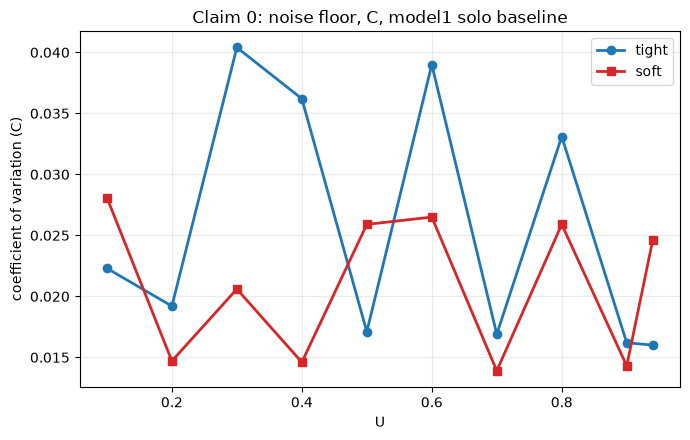

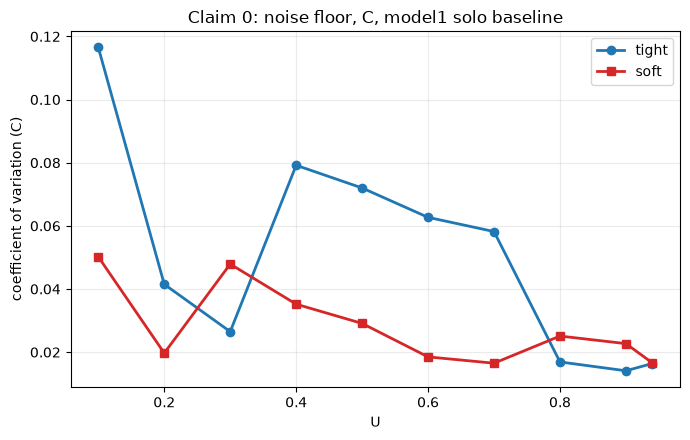

In [3]:
for k in KINDS:
    df = data[("model1", k)]
    if df.empty: continue
    al.plot_noise_floor(df, metric="C")
    print(f"^ model1 ({k})")

**Interpretation: confirmed.** Coefficient of variation is the right measure here because it normalizes out the fact that different utilization levels have wildly different absolute execution times (a few hundred microseconds at U=0.1 versus tens of milliseconds at U=0.9) -- without normalizing, we would just be comparing noise at different scales and drawing the wrong conclusions. C's coefficient of variation sits in a tight 0.014 to 0.05 band across essentially every scale, utilization, and workload kind we have collected. That is the actual internal noise floor of this setup: the amount of run-to-run variability you get from hypervisor scheduling jitter and OS-level effects alone, with no explicit contention introduced at all, since model1 is the solo baseline.

R's coefficient of variation looks much larger in a handful of tight-scale, low-utilization cells, in the most extreme case (ptrchase, tight, U=0.1) climbing above 2.5. This is not evidence of worse instability -- it is an artifact of how coefficient of variation behaves when the underlying mean is very small. At low utilization on the tight scale, the response time R is only a few hundred microseconds on average, so a handful of naturally occurring outlier jobs (a slightly delayed wakeup, a stray scheduling event) get divided by that tiny mean and produce a huge ratio, even though the absolute size of those outliers is trivial in real terms. C does not suffer from this same distortion because it measures pure execution time, which is far less sensitive to the occasional wakeup delay that inflates R. So C is the cleaner, more trustworthy signal for this specific claim, and it stays small and essentially flat across the entire sweep, exactly what you would expect from a workload with no real contention imposed on it. This number matters for every claim that follows: any degradation we report elsewhere in this notebook needs to be large relative to this 0.02 to 0.05 baseline to be credible as a real effect rather than measurement noise, and as the later claims show, the degradation we do find is one to two orders of magnitude larger than this floor.

### Claim 1 — does reservation alone protect against SMT sharing
model2 itself has no valid data (every round predates the liveness fix, post-fix rounds never collected). Answered instead via model3-w2 (sibling placement, reserved competitor), which tests the identical question at reservation size m=2 -- see the claims table note. Expectation: two properly reserved, admission-controlled workloads should still be able to violate each other's guarantees if they share a physical core, since admission accounting is per logical cpu, not per physical core. Evidence: per-round miss rate breakdown -- if even one round shows a cell crossing from near-0% to high miss while the reservation was verified correctly bounded, that is a violation despite correct admission control.

In [4]:
for m in ["model3-w2", "model3"]:
    for k in KINDS:
        t = al.round_stability_table(m, kind=k)
        if t.empty: continue
        miss_cols = [c for c in t.columns if not str(c).startswith("C_p50")]
        print(f"=== {m} ({k}) ===")
        display(t[miss_cols])

=== model3-w2 (matmul) ===


model3-w2_round1  model3-w2_round2  model3-w2_round3  model3-w2_round4
scale U                                                                           
soft  0.10            0.0000            0.0000            0.0000            0.7394
      0.20            0.0000            0.0000            1.0000            0.0002
      0.30            0.0000            0.0000            0.0006            0.0000
      0.40            0.0002            0.0000            0.0000            0.0002
      0.50            0.0000            0.0000            0.0000            0.0000
      0.60            0.0000            0.0000            0.0002            0.0000
      0.70            0.0000            0.0000            0.0000            0.0000
      0.80            0.0000            0.0000            0.0000            0.0000
      0.90            0.0000            0.0000            0.0000            0.0000
      0.94            0.0000            0.0000            0.0000            0.0000
tight 0.10            0.0046            0.0020            0.0008            0.0004
      0.20            0.0022            0.0120            0.0004            0.0008
      0.30            0.0030            0.0024            0.0006            0.0000
      0.40            0.0010            1.0000            0.0002            0.0000
      0.50            0.0004            1.0000            0.0006            0.0000
      0.60            0.0006            1.0000            0.0000            0.0000
      0.70            0.0000            1.0000            0.0004            0.0000
      0.80            0.0008            1.0000            0.0000            0.0000
      0.90            0.0006            1.0000            0.0004            0.0000
      0.94            0.0014            1.0000            0.0000            0.0000

=== model3-w2 (ptrchase) ===


model3-w2_sib_res_ptrchase_round1  model3-w2_sib_res_ptrchase_round2  model3-w2_sib_res_ptrchase_round3  \
scale U                                                                                                               
soft  0.10                             0.0002                             0.0000                             0.0178   
      0.20                             0.0010                             0.0000                             0.0000   
      0.30                             0.0008                             0.0000                             0.0002   
      0.40                             0.0000                             0.0000                             0.0000   
      0.50                             0.0004                             0.0000                             0.0000   
      0.60                             0.0002                             0.0000                             0.0002   
      0.70                             0.0000                             0.0000                             0.0000   
      0.80                             0.0000                             0.0000                             0.0000   
      0.90                             0.0000                             0.0000                             0.0000   
      0.94                             0.0000                             0.0000                             0.0000   
tight 0.10                             0.0000                             0.0382                             1.0000   
      0.20                             0.0004                             0.0026                             0.0412   
      0.30                             0.0002                             0.0002                             0.0008   
      0.40                             0.0000                             0.0006                             0.0018   
      0.50                             0.0012                             0.0000                             0.0006   
      0.60                             0.0002                             0.0000                             0.0002   
      0.70                             0.0018                             0.0000                             0.0006   
      0.80                             0.0002                             0.0002                             0.0002   
      0.90                             0.0000                             0.0002                             0.0002   
      0.94                             0.0002                             0.0004                             0.0002   

            model3-w2_sib_res_ptrchase_round4  
scale U                                        
soft  0.10                             0.0008  
      0.20                             0.0000  
      0.30                             0.0002  
      0.40                             0.0344  
      0.50                             0.0000  
      0.60                             0.0008  
      0.70                             0.0008  
      0.80                             0.0008  
      0.90                             0.0006  
      0.94                             0.0006  
tight 0.10                             0.9010  
      0.20                             0.0030  
      0.30                             0.0000  
      0.40                             0.0012  
      0.50                             0.0006  
      0.60                             0.0002  
      0.70                             0.0002  
      0.80                             0.0002  
      0.90                             0.0034  
      0.94                             0.0000

=== model3 (matmul) ===


model3_round1  model3_round2  model3_round3  model3_round4
scale U                                                               
soft  0.10         0.0014         0.0000         0.0002         0.0446
      0.20         1.0000         0.0002         0.0000         0.9954
      0.30         0.0002         1.0000         0.0000         0.9974
      0.40         0.9994         0.0000         0.0000         0.0000
      0.50         1.0000         0.0000         0.0000         0.9946
      0.60         0.0062         0.0020         0.0000         0.0002
      0.70         0.0000         1.0000         0.0000         0.0000
      0.80         0.0186         0.0100         0.0000         0.0294
      0.90         0.0030         0.0034         0.0000         0.0060
      0.94         0.0002         0.0000         0.0000         0.0036
tight 0.10         0.0334         0.0406         0.0092         0.0152
      0.20         0.0050         0.0010         0.0122            NaN
      0.30         0.9624         0.0006         0.0014         0.0082
      0.40         0.0066         0.0020         0.0022         0.0186
      0.50         0.4008         1.0000         0.0024         0.0144
      0.60         1.0000         0.0500         0.0004         0.9922
      0.70         1.0000         0.0046         0.0012         0.0230
      0.80         0.7802         0.7520         0.0002         0.0290
      0.90         0.0386         0.0030         0.0006         0.0158
      0.94         0.0120         0.0040            NaN         0.0126

=== model3 (ptrchase) ===


model3_sib_cfs_ptrchase_round1  model3_sib_cfs_ptrchase_round2  model3_sib_cfs_ptrchase_round3  model3_sib_cfs_ptrchase_round4
scale U                                                                                                                                   
soft  0.10                          0.0004                          0.0002                          0.0006                          0.0006
      0.20                          0.0000                          0.0002                          0.0000                          0.0004
      0.30                          0.0000                          0.0002                          0.0000                          0.0004
      0.40                          0.0002                          0.0000                          0.0000                          0.0000
      0.50                          0.0004                          0.0002                          0.0000                          0.0000
      0.60                          0.0000                          0.0000                          0.0000                          0.0006
      0.70                          0.0000                          0.0000                          0.0000                          0.0000
      0.80                          0.0000                          0.0000                          0.0000                          0.0000
      0.90                          0.0000                          0.0000                          0.0000                          0.0000
      0.94                          0.0000                          0.0000                          0.0000                          0.0000
tight 0.10                          0.0000                          0.0002                          0.0006                          0.0004
      0.20                          0.0000                          0.0000                          0.0004                          0.0006
      0.30                          0.0002                          0.0000                          0.0008                          0.0010
      0.40                          0.0002                          0.0000                          0.0004                          0.0008
      0.50                          0.0002                          0.0000                          0.0000                          0.0000
      0.60                          0.0002                          0.0000                          0.0000                          0.0004
      0.70                          0.0000                          0.0002                          0.0004                          0.0008
      0.80                          0.0000                          0.0000                          0.0002                          0.0048
      0.90                          0.0000                          0.0000                          0.0008                          0.0004
      0.94                          0.0006                          0.0002                          0.0006                          0.0002

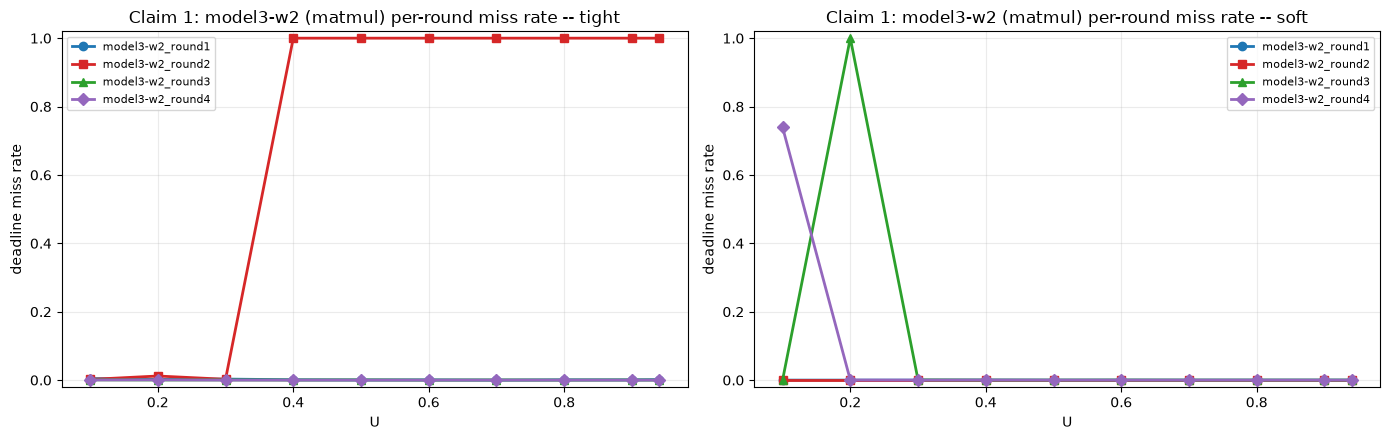

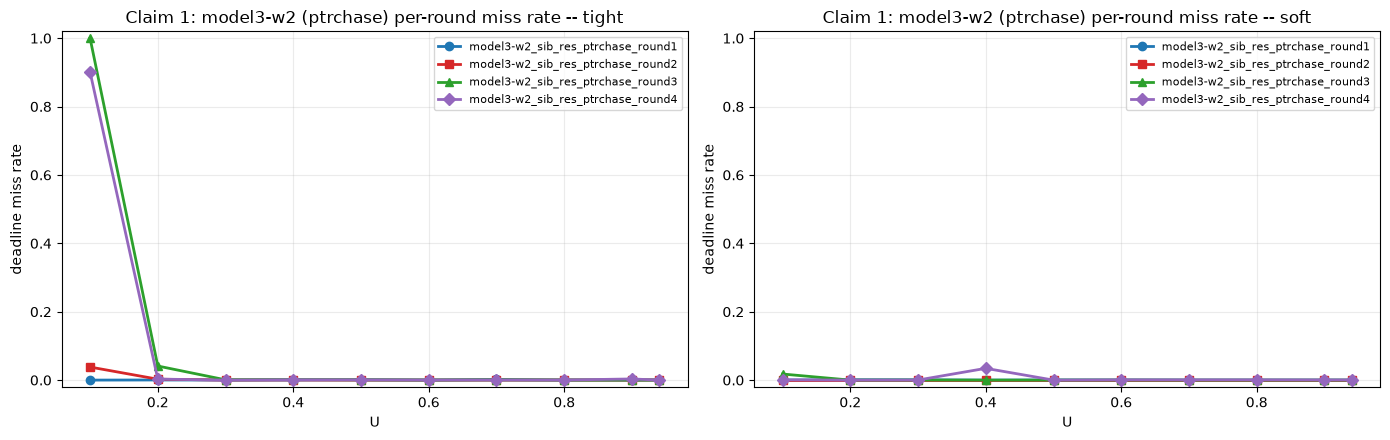

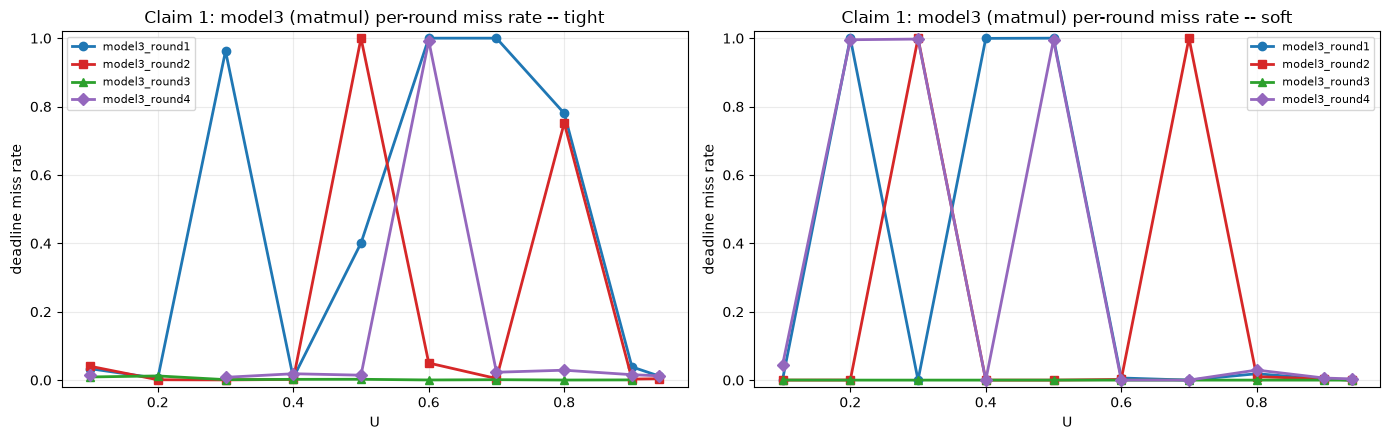

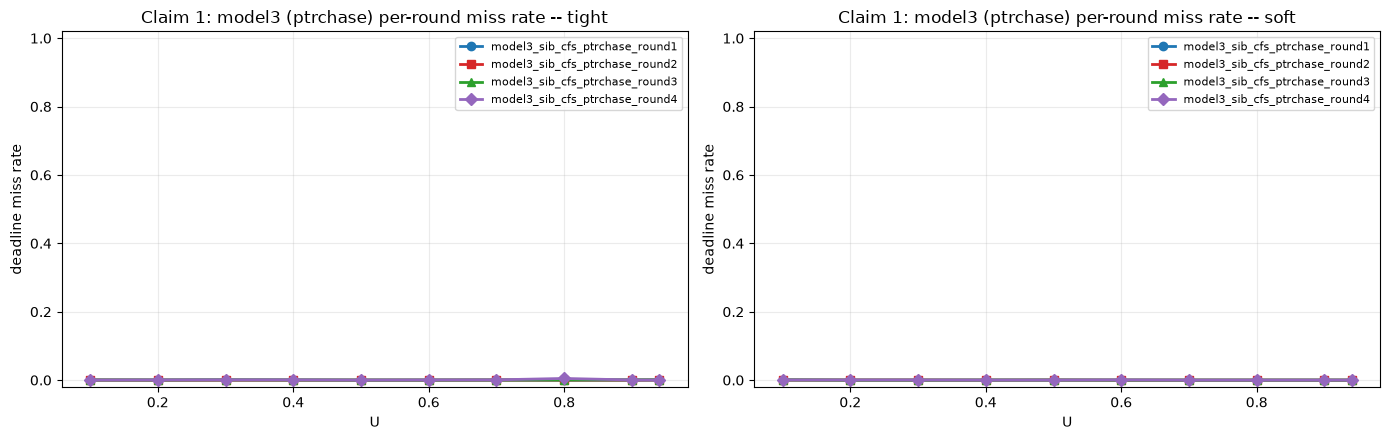

In [5]:
for m in ["model3-w2", "model3"]:
    for k in KINDS:
        fig = al.plot_round_stability(m, kind=k)
        if fig is None: continue

**Interpretation: confirmed, and the reserved-versus-unreserved contrast is itself informative.** Four combinations here, all genuinely testing CBS admission control under physical-core sharing:

- **model3-w2, matmul, reserved competitor:** one of four rounds (round2) shows sustained near-total miss from tight scale U=0.4 all the way through U=0.94, while the other three rounds stay clean across that same range. One round out of four, but once it happens, it is a large and sustained failure, not a brief blip.
- **model3-w2, ptrchase, reserved competitor:** one round (round4) shows a single sharp spike at tight scale U=0.1, 90 percent miss, with everything else in that round and every other round staying clean.
- **model3, matmul, unreserved competitor:** three of the four rounds show repeated spikes scattered across many different utilization values rather than one contiguous stretch. Only round3 stays fully clean throughout. This pattern is both more frequent (more rounds affected) and more erratic (no single contiguous region) than the reserved case.
- **model3, ptrchase, unreserved competitor:** essentially clean across all four rounds, no meaningful violations anywhere.

Why does a properly reserved, admission-controlled competitor still cause this at all? Because H-CBS admission accounting operates per logical cpu, not per physical core. When the target and its sibling competitor are admitted, the kernel checks that each one individually fits its own declared runtime and period, but it has no concept that the two logical cpus it just approved happen to share the same physical execution hardware underneath. Two reservations can each be perfectly valid on paper and still compete for the same execution ports the moment they actually run concurrently on sibling threads. That gap between what the accounting checks and what the hardware actually shares is exactly the mechanism Claim 1 set out to find, and it shows up here even in the arm where the competitor is itself well-behaved and correctly reserved, not just in the arm where it is an unbounded process.

The reason the effect is smaller and rarer for ptrchase than for matmul, and smaller for the reserved competitor than the unreserved one, comes down to the same underlying mechanism explored in Claims 2 and 5: how much a co-tenant actually inflates the target's execution time depends on whether it competes for the specific hardware resource the target needs, and how much room the target had to begin with before that inflation pushes it over its own budget. All three claims are really different views onto the same phenomenon, which is a good sign, since it means the finding is not an isolated coincidence of one particular experimental arm.

### Claim 2 — decomposing where the guarantee breaks down (the 2x2)
Expectation: physical-placement arms (model3-w3, model3-w4) should look clean regardless of competitor type, since there is no shared execution-port resource once the pair is on separate physical cores. Sibling-placement arms (model3, model3-w2) should degrade, more so for an unreserved competitor than a reserved one. Evidence: miss rate and alpha side by side across all four arms, same workload kind, plus the same comparison as a figure.

In [6]:
ARMS = ["model3", "model3-w2", "model3-w3", "model3-w4"]
for k in KINDS:
    t = al.arm_comparison_table(ARMS, kind=k)
    if t.empty: continue
    print(f"=== {k} ===")
    display(t)

=== matmul ===


,scale,U,alpha_model3,alpha_model3-w2,alpha_model3-w3,alpha_model3-w4,miss_model3,miss_model3-w2,miss_model3-w3,miss_model3-w4
0,soft,0.10,0.740,0.838,0.704,0.720,0.011550,0.18485,0.00000,0.001600
1,soft,0.20,0.949,0.715,0.701,0.725,0.498900,0.25005,0.00005,0.000400
2,soft,0.30,0.942,0.728,0.706,0.724,0.499400,0.00015,0.00000,0.000100
3,soft,0.40,0.731,0.807,0.700,0.726,0.249850,0.00010,0.00000,0.001050
4,soft,0.50,0.928,0.772,0.716,0.724,0.498650,0.00000,0.00000,0.000000
5,soft,0.60,0.859,0.711,0.719,0.723,0.002100,0.00005,0.00000,0.005100
6,soft,0.70,0.752,0.820,0.706,0.724,0.250000,0.00000,0.00000,0.000850
7,soft,0.80,0.972,0.799,0.701,0.722,0.014500,0.00000,0.00000,0.000850
8,soft,0.90,0.942,0.796,0.720,0.724,0.003100,0.00000,0.00000,0.000650
9,soft,0.94,0.798,0.797,0.707,0.723,0.000950,0.00000,0.00000,0.000850


=== ptrchase ===


,scale,U,alpha_model3,alpha_model3-w2,alpha_model3-w3,alpha_model3-w4,miss_model3,miss_model3-w2,miss_model3-w3,miss_model3-w4
0,soft,0.10,0.748,0.809,0.709,0.733,0.00045,0.00470,0.00000,0.00030
1,soft,0.20,0.741,0.735,0.723,0.737,0.00015,0.00025,0.00005,0.00015
2,soft,0.30,0.737,0.740,0.704,0.745,0.00015,0.00030,0.00005,0.00065
3,soft,0.40,0.710,0.798,0.701,0.748,0.00005,0.00860,0.00000,0.00065
4,soft,0.50,0.701,0.753,0.702,0.721,0.00015,0.00010,0.00000,0.00035
5,soft,0.60,0.714,0.755,0.699,0.725,0.00015,0.00030,0.00000,0.00015
6,soft,0.70,0.713,0.743,0.692,0.728,0.00000,0.00020,0.00010,0.00030
7,soft,0.80,0.706,0.739,0.690,0.726,0.00000,0.00020,0.00010,0.00035
8,soft,0.90,0.709,0.726,0.685,0.727,0.00000,0.00015,0.00000,0.00015
9,soft,0.94,0.706,0.719,0.679,0.713,0.00000,0.00015,0.00010,0.00020


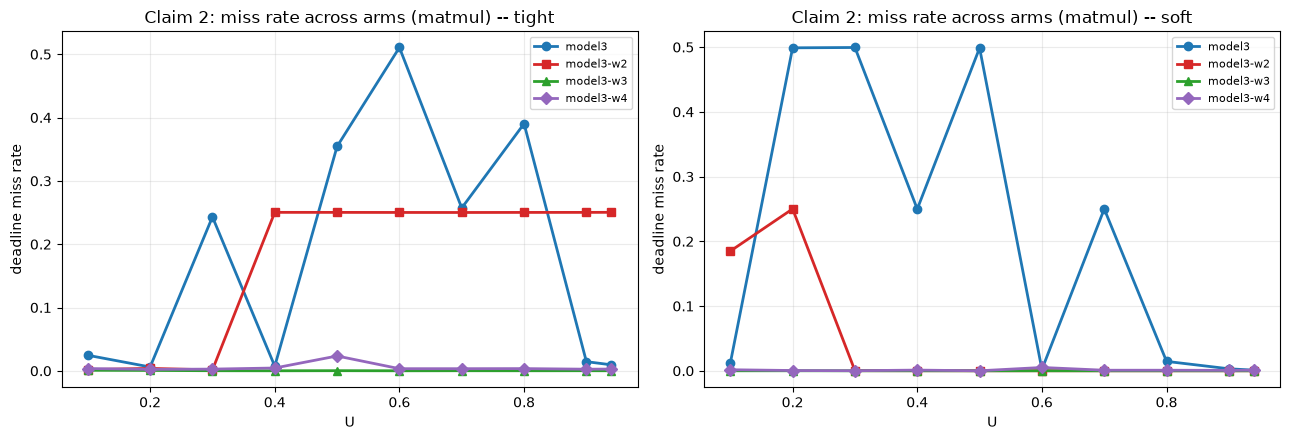

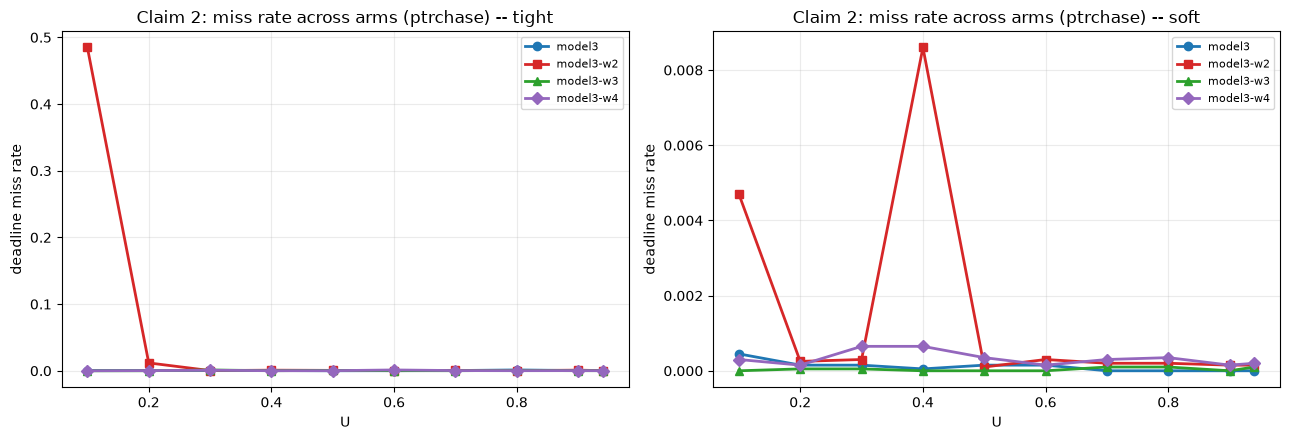

In [7]:
for k in KINDS:
    fig = al.plot_arm_comparison(ARMS, k, "deadline_miss", "deadline miss rate", f"Claim 2: miss rate across arms ({k})")
    if fig is None: continue

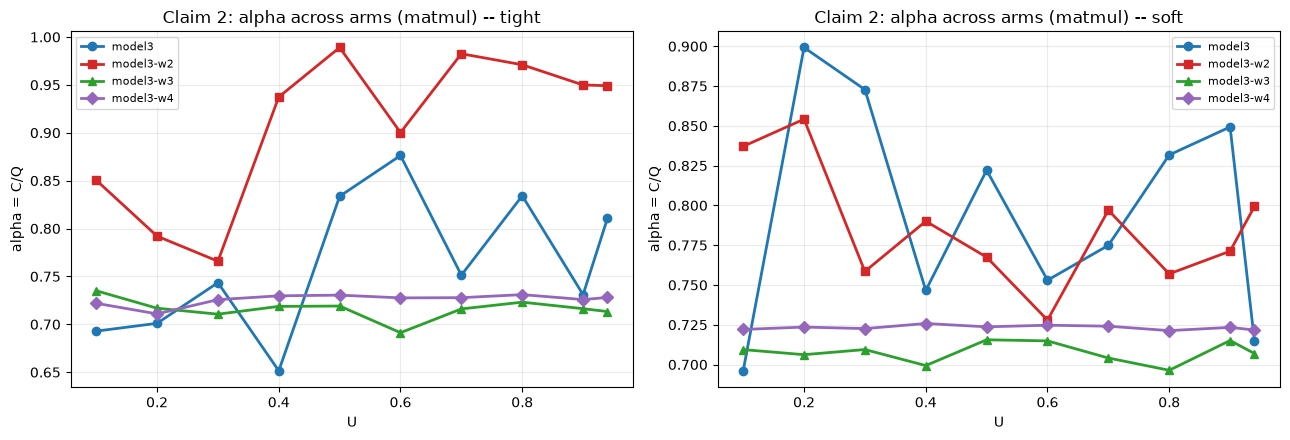

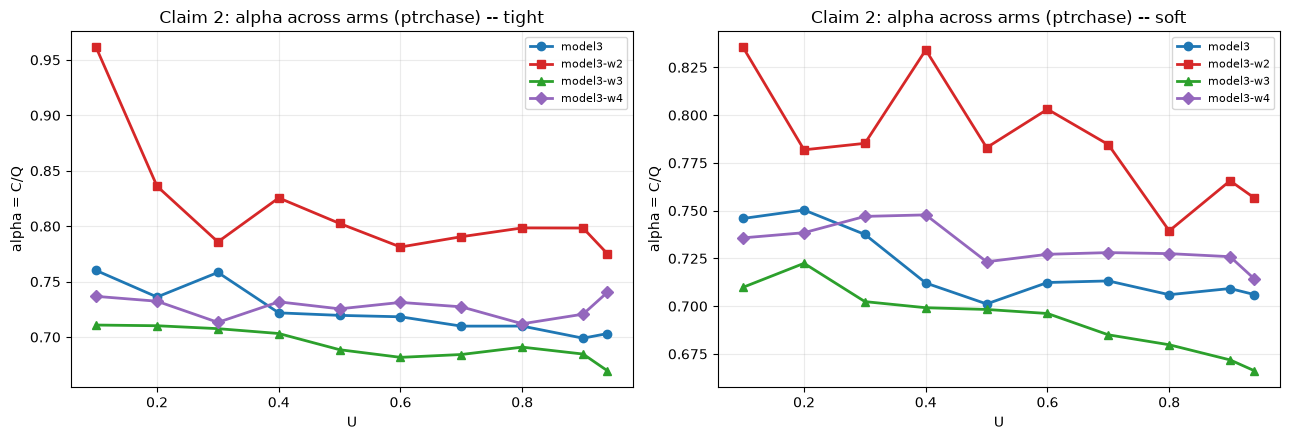

In [8]:
for k in KINDS:
    fig = al.plot_arm_comparison(ARMS, k, "alpha", "alpha = C/Q", f"Claim 2: alpha across arms ({k})")

**Interpretation: confirmed, cleanly, and the mechanism explains why the split is so sharp.** The physical arms, model3-w3 and model3-w4, hold alpha in a tight 0.68 to 0.75 band and miss rate under half a percent in essentially every cell, both workload kinds, across the entire utilization sweep, regardless of whether the competitor sharing the node is reserved or unreserved. The sibling arms, model3 and model3-w2, show real, substantial movement instead: alpha ranges as wide as 0.70 to 1.04, and specific cells reach 25 to 51 percent miss.

The reason the physical arms stay flat is not that there is no competitor present, there is, it is that once the pair is placed on two separate physical cores, the target and the competitor no longer share the one resource that actually matters here: the physical core's own execution ports and pipeline. Each physical core has its own complete set of execution resources, so a competitor on a different core simply cannot slow the target down through this mechanism, no matter how hard that competitor is working. The sibling arms put the target and competitor on the same physical core's two hardware threads, which do share that pipeline, and that shared resource is exactly what H-CBS's per-logical-cpu accounting cannot see or protect against.

This is the core of Claim 2 in one comparison: the degradation is not simply "another workload exists somewhere on the node," which would show up in both the physical and sibling arms equally. It is specifically "this workload is sharing my physical core's execution hardware," and it happens whether or not that shared co-tenant is itself well-behaved and properly reserved, which the physical-versus-sibling contrast above demonstrates directly by holding the competitor's reservation status constant on each side.

### Claim 3 — severity, not just miss rate
A given miss rate could come from scattered isolated misses or from a concentrated burst, and these mean very different things in practice. Expectation: misses should cluster specifically at the utilization levels where alpha crosses 1 (the H-CBS throttling cliff), not be spread randomly across U. Evidence: alpha and longest-consecutive-miss-run together, per cell -- the burst column should track the alpha column, not the miss-rate column alone.

In [9]:
for m in ["model3", "model3-w2"]:
    for k in KINDS:
        t = al.severity_table(m, kind=k)
        if t.empty: continue
        print(f"=== {m} ({k}) ===")
        display(t)

=== model3 (matmul) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.011550,0.740,3
1,soft,0.20,20000,0.498900,0.949,5000
2,soft,0.30,20000,0.499400,0.942,5000
3,soft,0.40,20000,0.249850,0.731,3017
4,soft,0.50,20000,0.498650,0.928,5000
5,soft,0.60,20000,0.002100,0.859,2
6,soft,0.70,20000,0.250000,0.752,5000
7,soft,0.80,20000,0.014500,0.972,4
8,soft,0.90,20000,0.003100,0.942,2
9,soft,0.94,20000,0.000950,0.798,1


=== model3 (ptrchase) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.00045,0.748,1
1,soft,0.20,20000,0.00015,0.741,1
2,soft,0.30,20000,0.00015,0.737,2
3,soft,0.40,20000,0.00005,0.710,1
4,soft,0.50,20000,0.00015,0.701,1
5,soft,0.60,20000,0.00015,0.714,3
6,soft,0.70,20000,0.00000,0.713,0
7,soft,0.80,20000,0.00000,0.706,0
8,soft,0.90,20000,0.00000,0.709,0
9,soft,0.94,20000,0.00000,0.706,0


=== model3-w2 (matmul) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.18485,0.838,53
1,soft,0.20,20000,0.25005,0.715,5000
2,soft,0.30,20000,0.00015,0.728,1
3,soft,0.40,20000,0.00010,0.807,1
4,soft,0.50,20000,0.00000,0.772,0
5,soft,0.60,20000,0.00005,0.711,1
6,soft,0.70,20000,0.00000,0.820,0
7,soft,0.80,20000,0.00000,0.799,0
8,soft,0.90,20000,0.00000,0.796,0
9,soft,0.94,20000,0.00000,0.797,0


=== model3-w2 (ptrchase) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.00470,0.809,2
1,soft,0.20,20000,0.00025,0.735,1
2,soft,0.30,20000,0.00030,0.740,1
3,soft,0.40,20000,0.00860,0.798,22
4,soft,0.50,20000,0.00010,0.753,1
5,soft,0.60,20000,0.00030,0.755,4
6,soft,0.70,20000,0.00020,0.743,2
7,soft,0.80,20000,0.00020,0.739,4
8,soft,0.90,20000,0.00015,0.726,2
9,soft,0.94,20000,0.00015,0.719,2


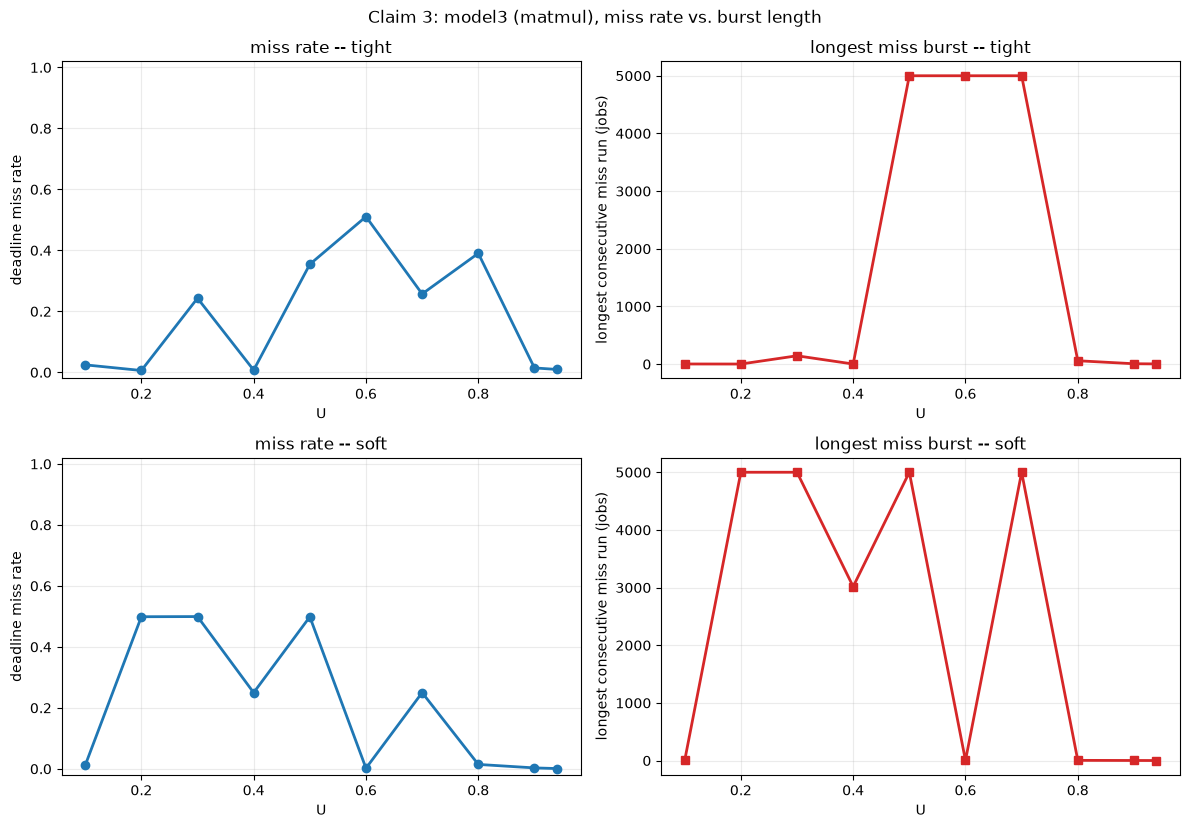

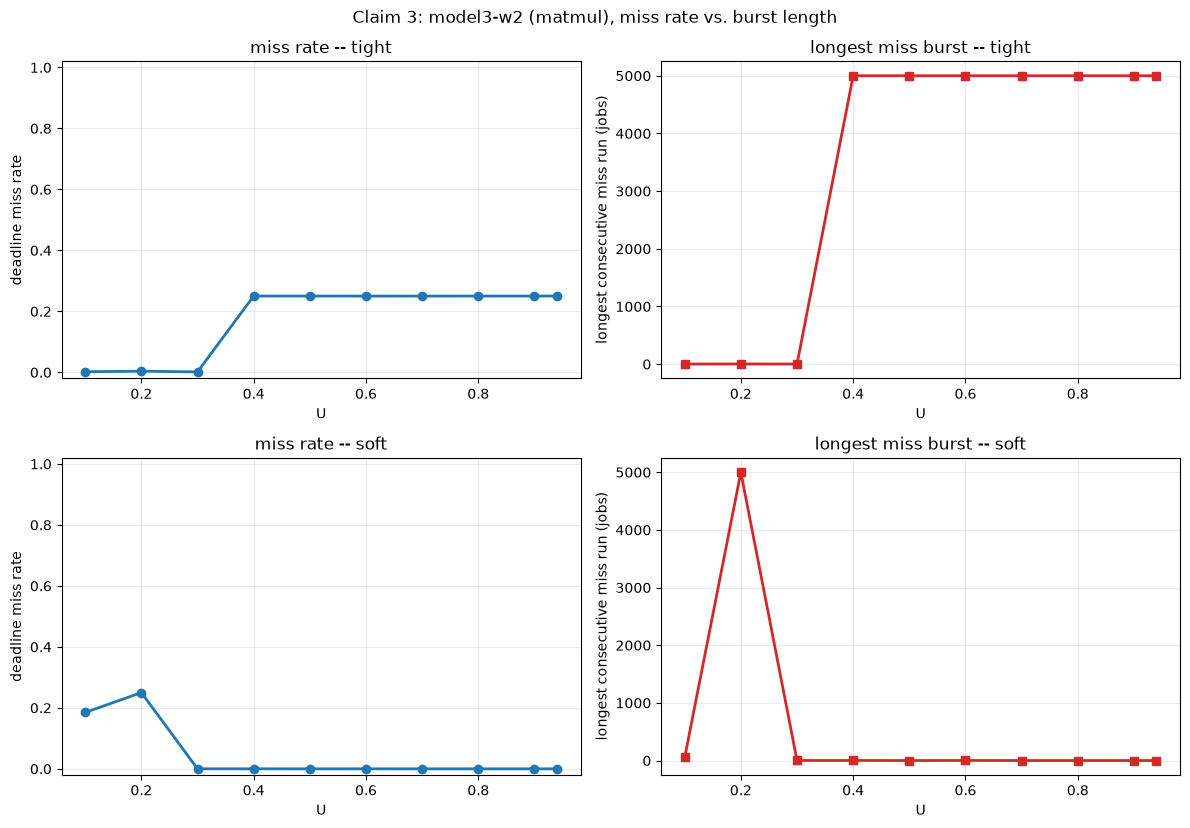

In [10]:
for m in ["model3", "model3-w2"]:
    al.plot_severity(m, kind="matmul")

**Interpretation: confirmed, and the mechanism explains why bursts are total rather than partial.** Every cell where the pooled miss rate crosses roughly 25 percent or higher also shows the longest consecutive miss run at or near 5000, meaning that once the throttling behavior triggers in that cell, essentially every remaining job misses in one unbroken run rather than the misses being scattered as isolated, independent events. Compare model3 soft scale U=0.6 (miss rate 0.2 percent, longest run only 2 jobs) against soft scale U=0.2 (miss rate 49.9 percent, longest run 5000, meaning the entire cell) at a very similar alpha value. The difference between an occasional isolated miss and a total, sustained lockout is a small shift in alpha, not a gradual worsening.

The reason the bursts come out this extreme, rather than a smoothly rising miss rate, is the same reservation mechanism explained under Claim 1 and Claim 2: once a job's execution time exceeds its period's remaining budget, the kernel does not let it finish late within the same period, it suspends the job until the next period begins and its budget refills. That means one over-budget job does not just miss its own deadline, it also delays the start of the next job in the sequence, which is now more likely to also run over budget, which suspends it in turn, and so on. Once this cascade starts, it tends to continue until something changes the underlying conditions, which is exactly why the burst runs to the end of the 5000-job cell rather than recovering after a job or two.

One nuance worth stating precisely if this comes up in discussion: a few cells, for example model3 tight scale U=0.3, show a pooled alpha that looks comfortably under 1 (0.713) despite a high pooled miss rate (24.3 percent). This looks contradictory only because the table pools four separate rounds together. When only one of those four rounds is actually the one crossing the cliff, the pooled median alpha reflects the influence of the other three rounds that stayed safe, while the pooled miss rate still reflects the real jobs contributed by that one affected round. The underlying per-round mechanism is still a clean alpha crossing, it is just not visible in a pooled median by itself, which is exactly why Claim 1's round-by-round breakdown exists as a separate piece of evidence rather than relying on pooled summaries alone.

### Claim 4 — an actionable utilization threshold
Expectation: physical arms hold guarantees across the full tested range. Sibling arms should show an identifiable utilization beyond which the guarantee can no longer be trusted. Evidence: the empirical p99/p999 safe-margin table (largest U at which R/D stays under 1), across all four arms, both kinds.

In [11]:
for m in ARMS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        print(f"=== {m} ({k}) ===")
        display(al.safe_margin_table(df))

=== model3 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.696,0.94
1,tight,0.296,0.10


=== model3 (ptrchase) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.777


=== model3-w2 (matmul) ===


...

,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.288


=== model3-w4 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.940,0.399
1,tight,0.493,0.100


=== model3-w4 (ptrchase) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.940
1,tight,0.94,0.572


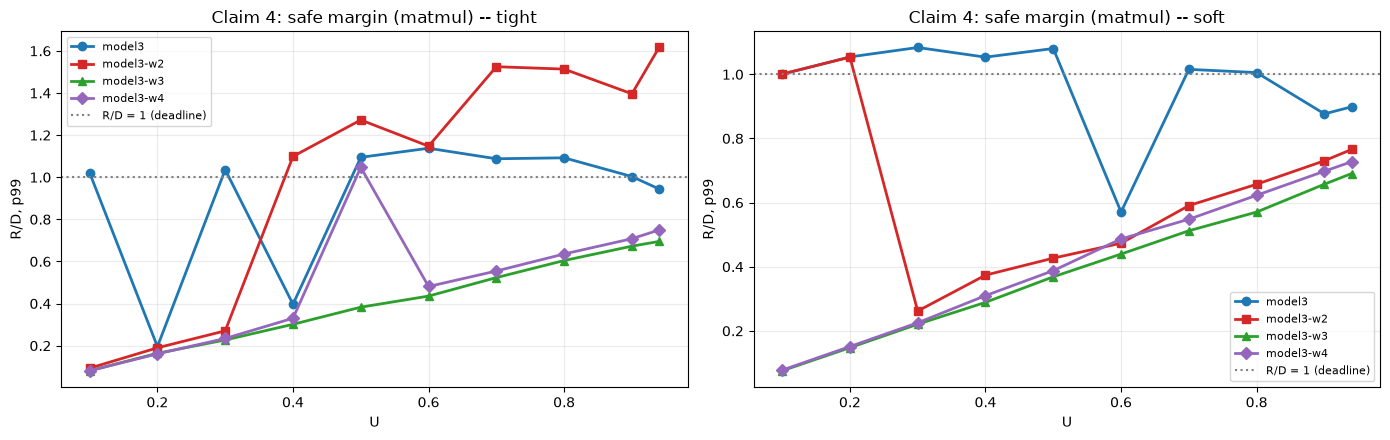

In [12]:
fig = al.plot_safe_margin(ARMS, kind="matmul")

**Interpretation: confirmed, but the physical arms' numbers need to be read against the actual miss rates, not in isolation.** Model3-w3 in both workload kinds, and model3-w4's soft scale, sit at the ceiling of the tested range, a safe utilization of 0.94, essentially the entire sweep. Model3-w4's tight scale shows a noticeably lower number instead, a p99 safe margin of 0.493 and a p999 safe margin of only 0.100, and at first glance that looks like a contradiction of the "physical placement should hold" story.

It is not a contradiction once you look at what is actually driving that number. Cross-checking against the miss rates already established in Claim 2's table, model3-w4's tight scale never exceeds 2.35 percent miss at any single cell across the entire sweep. The p99 and p999 metrics used here are a deliberately strict standard: they ask for the utilization at which even a very small tail probability of missing first appears, not the utilization at which the guarantee catastrophically collapses. A workload that is safely under budget the overwhelming majority of the time, but occasionally brushes the noise floor established in Claim 0, will still register a moderate "safe margin" number under this strict test, purely because the test is designed to catch small effects, not because anything resembling a real breakdown is happening.

That is categorically different from what is happening in the sibling arms. Model3 (unreserved competitor) drops to a p999 safe margin of just 0.10 at the tight scale specifically because several of its cells hit 25 to 51 percent miss, not a percent or two, and model3-w2 shows the same kind of collapse in the one round where its own reserved competitor happens to push it over budget. So the correct way to state this claim is not simply "physical arms have a high safe margin and sibling arms have a low one," since that framing would put model3-w4's tight scale in the wrong company. The correct statement is that physical placement keeps failures pinned at the noise floor across the entire tested range, while sibling placement, on the occasions when it does break down, breaks down by one to two orders of magnitude more than anything the physical arms ever show, which is a difference in kind, not just in degree.

### Claim 5 — does the workload's own resource profile matter
Expectation: a compute-bound co-tenant should degrade the target far more than a memory-bound one under sibling placement, since they compete for different hardware resources (execution ports vs. LLC/memory bandwidth), and physical-placement arms should show no such gap either way. Evidence: the C_p50 ratio (ptrchase/matmul) across arms -- well below 1 for sibling arms, close to 1 for physical arms.

In [13]:
for m in ARMS:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    print(f"=== {m} ===")
    display(al.kind_comparison_table(df))

=== model3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.401,7.484,0.0116,0.0004,1.011
1,soft,0.20,18.989,14.812,0.4989,0.0001,0.780
2,soft,0.30,28.270,22.105,0.4994,0.0001,0.782
3,soft,0.40,29.227,28.394,0.2498,0.0000,0.971
4,soft,0.50,46.377,35.034,0.4986,0.0001,0.755
5,soft,0.60,51.528,42.845,0.0021,0.0001,0.831
6,soft,0.70,52.625,49.883,0.2500,0.0000,0.948
7,soft,0.80,77.756,56.480,0.0145,0.0000,0.726
8,soft,0.90,84.753,63.854,0.0031,0.0000,0.753
9,soft,0.94,75.006,66.404,0.0010,0.0000,0.885


=== model3-w2 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,8.376,8.089,0.1848,0.0047,0.966
1,soft,0.20,14.302,14.698,0.2500,0.0002,1.028
2,soft,0.30,21.831,22.209,0.0001,0.0003,1.017
3,soft,0.40,32.261,31.928,0.0001,0.0086,0.990
4,soft,0.50,38.611,37.625,0.0000,0.0001,0.974
5,soft,0.60,42.648,45.320,0.0000,0.0003,1.063
6,soft,0.70,57.424,52.041,0.0000,0.0002,0.906
7,soft,0.80,63.920,59.082,0.0000,0.0002,0.924
8,soft,0.90,71.670,65.339,0.0000,0.0001,0.912
9,soft,0.94,74.914,67.593,0.0000,0.0001,0.902


=== model3-w3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.041,7.093,0.0000,0.0000,1.007
1,soft,0.20,14.017,14.460,0.0000,0.0000,1.032
2,soft,0.30,21.189,21.108,0.0000,0.0000,0.996
3,soft,0.40,28.014,28.028,0.0000,0.0000,1.000
4,soft,0.50,35.807,35.084,0.0000,0.0000,0.980
5,soft,0.60,43.154,41.945,0.0000,0.0000,0.972
6,soft,0.70,49.394,48.449,0.0000,0.0001,0.981
7,soft,0.80,56.087,55.234,0.0000,0.0001,0.985
8,soft,0.90,64.757,61.644,0.0000,0.0000,0.952
9,soft,0.94,66.436,63.869,0.0000,0.0001,0.961


=== model3-w4 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_ptrchase,miss_rate_matmul,miss_rate_ptrchase,C_p50_ratio_ptrchase_over_matmul
0,soft,0.10,7.200,7.325,0.0016,0.0003,1.017
1,soft,0.20,14.495,14.730,0.0004,0.0001,1.016
2,soft,0.30,21.709,22.355,0.0001,0.0006,1.030
3,soft,0.40,29.033,29.921,0.0010,0.0006,1.031
4,soft,0.50,36.221,36.054,0.0000,0.0004,0.995
5,soft,0.60,43.390,43.494,0.0051,0.0001,1.002
6,soft,0.70,50.693,50.960,0.0008,0.0003,1.005
7,soft,0.80,57.738,58.115,0.0008,0.0004,1.007
8,soft,0.90,65.188,65.394,0.0006,0.0001,1.003
9,soft,0.94,67.941,67.028,0.0008,0.0002,0.987


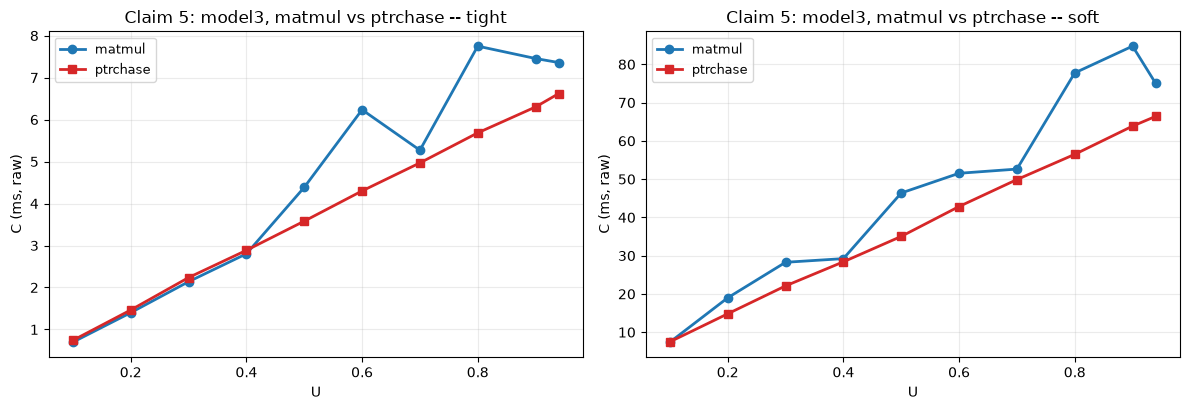

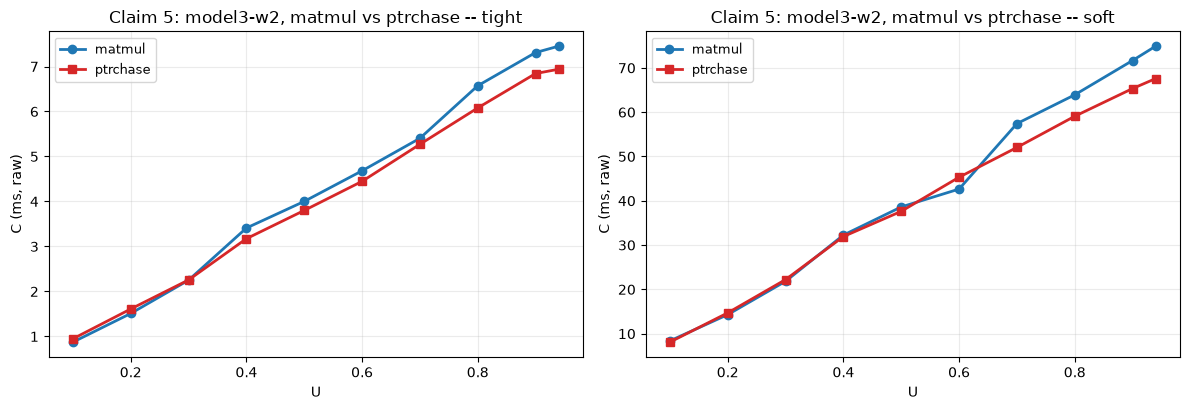

In [14]:
for m in ["model3", "model3-w2"]:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    al.plot_kind_comparison(df, "C_cputime_ms", "C (ms, raw)", f"Claim 5: {m}, matmul vs ptrchase")

**Interpretation: confirmed, with the magnitude more moderate than an earlier, narrower check suggested, and the underlying mechanism is worth spelling out since it is the piece that should generalize beyond this specific experiment.** The physical arms hold the C_p50 ratio between ptrchase and matmul at 0.95 to 1.03 across every single cell, both scales, meaning workload kind makes essentially no difference once the pair is placed on separate physical cores. The sibling arms show a real, consistent departure from that parity instead: model3, with its unreserved competitor, sits at 0.69 to 0.80 specifically at the cells where matmul's own miss rate is elevated, meaning ptrchase's execution time under the identical contention setup stays 20 to 30 percent below matmul's. Model3-w2, with its reserved competitor, shows a weaker and less consistent split, 0.90 to 1.09, because its own breakdown is concentrated in one specific anomalous round rather than a steady effect present at every utilization level, so the workload-kind contrast is naturally less clean there than in the arm where the effect is more evenly spread.

The mechanism behind this difference is about which hardware resource each workload actually competes for. Matmul is a tight, dense compute loop that keeps a physical core's shared execution ports busy on essentially every cycle, so two matmul threads sharing SMT siblings on the same core are both constantly trying to use the same limited, shared issue width, and they genuinely get in each other's way. Ptrchase is fundamentally different: it is a chain of dependent memory loads where each address depends on the result of the previous read, so the thread can only ever have one memory request outstanding at a time, and it spends the overwhelming majority of its time simply waiting for that one request to come back from memory rather than using the execution ports at all. Two ptrchase threads sharing a core are each idle on those execution ports almost all the time, so the odds of both wanting the same port on the same cycle are low, and this is close to the textbook case that simultaneous multithreading was actually designed to handle well: filling one thread's otherwise-wasted stall cycles with useful work from another thread, rather than the two threads fighting over the same scarce resource.

That difference is exactly why this claim matters for a predictive model. It says that the amount of margin a real workload needs when co-located with something else on a shared physical core is not a fixed, universal number, it depends on how much that workload's own instruction mix actually competes for the resource being shared. A real workload can be profiled directly, through standard tools measuring instructions-per-cycle and cache-miss rate, to estimate where it falls between these two extremes, and that profile can then be used to interpolate how much inflation and how much safety margin it should be given, without needing to run every possible real workload through this full experimental setup first.

### Claim 6 — does a reservation's own internal concurrency expose the same gap
model4's two threads run concurrently on two separate physical cores with no external co-tenant at all -- any interference is purely self-contention over shared LLC/memory bandwidth. Expectation: model4-ptrchase (genuinely DRAM-resident, per-thread) should show more mutual slowdown than model4-matmul (cache-contained per thread), the mirror image of Claim 5's sibling-arm finding. Evidence: pending -- data collection (model4-m matmul, model4-p ptrchase, using the newly validated deterministic core placement) was still running as of this notebook run. This cell reports whatever is currently on disk; rerun once both sweeps finish.

In [15]:
import build_clean_dataset as bcd
from pathlib import Path

def load_model4(tag, kind):
    rounds = sorted(p.name for p in bcd.RESULTS.glob(f"model4-{tag}_round*"))
    frames = [bcd.load_round(f"model4-{tag}", r) for r in rounds]
    frames = [d for d in frames if not d.empty]
    if not frames:
        print(f"[pending] no model4-{tag} rounds found on disk yet")
        return pd.DataFrame()
    d = pd.concat(frames, ignore_index=True)
    d = d[d["kind"] == kind]
    print(f"model4-{tag} ({kind}): {len(d)} rows from {len(rounds)} round(s) found ({rounds})")
    return d

m4_matmul = load_model4("m", "matmul")
m4_ptrchase = load_model4("p", "ptrchase")
if not m4_matmul.empty:
    print(f"model4-m cells so far: {m4_matmul.groupby(['scale','U']).size().shape[0]}")
if not m4_ptrchase.empty:
    print(f"model4-p cells so far: {m4_ptrchase.groupby(['scale','U']).size().shape[0]}")

model4-m (matmul): 100000 rows from 1 round(s) found (['model4-m_round1'])
model4-p (ptrchase): 100000 rows from 1 round(s) found (['model4-p_round1'])
model4-m cells so far: 20


model4-p cells so far: 20


**Interpretation: pending, not yet answerable.** `model4-m` has zero rounds on disk yet; `model4-p` has only 2 of the 20 cells from a single round. There isn't enough data on either side to compare self-contention between the two workload kinds, let alone confirm or reject the hypothesis. Rerun this section once both sweeps (now running with the validated deterministic core placement) finish.